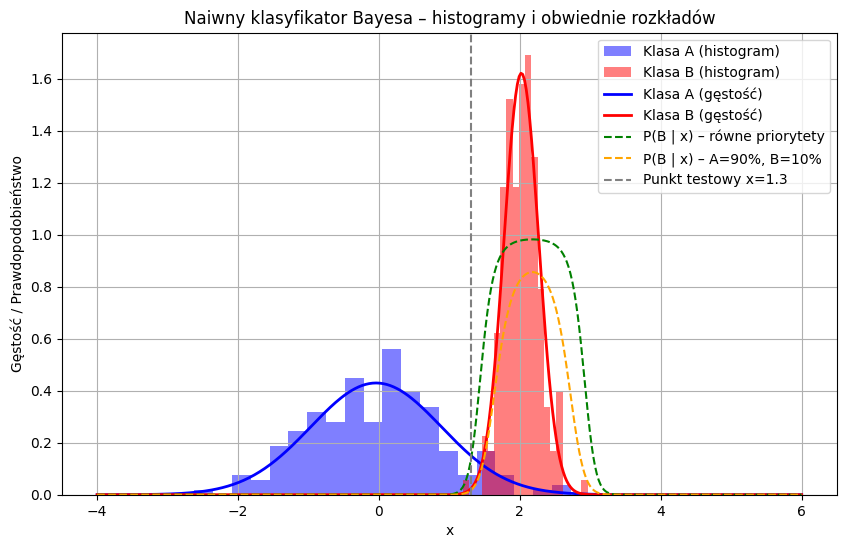

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from scipy.stats import norm

# ----- 1. Generowanie danych jednowymiarowych -----
np.random.seed(42)

A = np.random.normal(0, 1, 200)   # klasa A
B = np.random.normal(2, 0.25, 200)   # klasa B

X = np.hstack([A, B]).reshape(-1, 1)
y = np.array([0]*200 + [1]*200)

# ----- 2. Modele Bayesowskie -----
clf_equal = GaussianNB()                     # równe priorytety
clf_equal.fit(X, y)

clf_unequal = GaussianNB(priors=[0.9, 0.1])  # A = 90%, B = 10%
clf_unequal.fit(X, y)

# ----- 3. Siatka punktów -----
xx = np.linspace(-4, 6, 400).reshape(-1, 1)

# Prawdopodobieństwa predykcji
p_equal = clf_equal.predict_proba(xx)[:, 1]      # P(B | x)
p_unequal = clf_unequal.predict_proba(xx)[:, 1]  # P(B | x) z priorytetami

# Punkt testowy
test_x = 1.3

# ----- 4. Wykres histogramów i obwiedni -----
plt.figure(figsize=(10, 6))

# Histogramy klas
plt.hist(A, bins=20, density=True, alpha=0.5, color='blue', label="Klasa A (histogram)")
plt.hist(B, bins=20, density=True, alpha=0.5, color='red', label="Klasa B (histogram)")

# Obwiednie (gęstości) klas
x_vals = np.linspace(-4, 6, 400)
plt.plot(x_vals, norm.pdf(x_vals, np.mean(A), np.std(A)), color='blue', lw=2, label="Klasa A (gęstość)")
plt.plot(x_vals, norm.pdf(x_vals, np.mean(B), np.std(B)), color='red', lw=2, label="Klasa B (gęstość)")

# Linie poziomu Bayesa (dla równego priorytetu)
plt.plot(xx, p_equal, label="P(B | x) – równe priorytety", color='green', linestyle='--')

# Linie poziomu Bayesa (dla nierównych priorytetów)
plt.plot(xx, p_unequal, label="P(B | x) – A=90%, B=10%", color='orange', linestyle='--')

# Punkt testowy
plt.axvline(test_x, linestyle="--", color="gray", label="Punkt testowy x=1.3")

plt.xlabel("x")
plt.ylabel("Gęstość / Prawdopodobieństwo")
plt.title("Naiwny klasyfikator Bayesa – histogramy i obwiednie rozkładów")
plt.legend()
plt.grid(True)
plt.show()


In [2]:
# ----- 5. Dane testowe i predykcje -----
x=1.51
test_points = np.linspace(0, 2, 11).reshape(-1, 1)  # 11 punktów od 0 do 2

pred_equal = clf_equal.predict_proba(test_points)[:, 1]      # P(B | x) – równe priorytety
pred_unequal = clf_unequal.predict_proba(test_points)[:, 1]  # P(B | x) – A=90%, B=10%

# Tworzymy tablicę wyników
results = np.hstack([test_points, pred_equal.reshape(-1,1), pred_unequal.reshape(-1,1)])
print("x\tP(B|x) równe\tP(B|x) A=90%, B=10%")
for row in results:
    print(f"{row[0]:.2f}\t{row[1]:.4f}\t\t{row[2]:.4f}")


x	P(B|x) równe	P(B|x) A=90%, B=10%
0.00	0.0000		0.0000
0.20	0.0000		0.0000
0.40	0.0000		0.0000
0.60	0.0000		0.0000
0.80	0.0000		0.0000
1.00	0.0013		0.0001
1.20	0.0339		0.0039
1.40	0.3416		0.0545
1.60	0.8057		0.3155
1.80	0.9472		0.6660
2.00	0.9768		0.8237


In [3]:
# ----- 5. Dane testowe i predykcje -----
test_points = np.linspace(0, 4, 21).reshape(-1, 1)  # 11 punktów od 0 do 2

# Prawdopodobieństwa
pred_prob_equal = clf_equal.predict_proba(test_points)[:, 1]      # P(B | x) – równe priorytety
pred_prob_unequal = clf_unequal.predict_proba(test_points)[:, 1]  # P(B | x) – A=90%, B=10%

# Klasy przewidziane przez klasyfikatory (zamiana 0->A, 1->B)
pred_class_equal = np.array(['A' if c==0 else 'B' for c in clf_equal.predict(test_points)])
pred_class_unequal = np.array(['A' if c==0 else 'B' for c in clf_unequal.predict(test_points)])

# Wypisanie tabeli
print("x\tP(B|x) równe\tKlasa równe\tP(B|x) A=90%, B=10%\tKlasa A=90%,B=10%")
for x, p_eq, c_eq, p_un, c_un in zip(test_points.flatten(), pred_prob_equal, pred_class_equal, pred_prob_unequal, pred_class_unequal):
    print(f"{x:.2f}\t{p_eq:.4f}\t\t{c_eq}\t\t{p_un:.4f}\t\t\t{c_un}")


x	P(B|x) równe	Klasa równe	P(B|x) A=90%, B=10%	Klasa A=90%,B=10%
0.00	0.0000		A		0.0000			A
0.20	0.0000		A		0.0000			A
0.40	0.0000		A		0.0000			A
0.60	0.0000		A		0.0000			A
0.80	0.0000		A		0.0000			A
1.00	0.0013		A		0.0001			A
1.20	0.0339		A		0.0039			A
1.40	0.3416		A		0.0545			A
1.60	0.8057		B		0.3155			A
1.80	0.9472		B		0.6660			B
2.00	0.9768		B		0.8237			B
2.20	0.9816		B		0.8555			B
2.40	0.9734		B		0.8025			B
2.60	0.9314		B		0.6014			B
2.80	0.7319		B		0.2327			A
3.00	0.2289		A		0.0319			A
3.20	0.0172		A		0.0019			A
3.40	0.0006		A		0.0001			A
3.60	0.0000		A		0.0000			A
3.80	0.0000		A		0.0000			A
4.00	0.0000		A		0.0000			A


In [4]:
import numpy as np
from sklearn.naive_bayes import GaussianNB

# generacja danych 1D
A = np.random.normal(0, 1, 200).reshape(-1,1)
B = np.random.normal(2, 1, 200).reshape(-1,1)

X = np.vstack([A, B])
y = np.array([0]*200 + [1]*200)

clf_equal = GaussianNB()
clf_equal.fit(X, y)

# nierówne priorytety (A dominuje)
clf_unequal = GaussianNB(priors=[0.9, 0.1])
clf_unequal.fit(X, y)

test_point = np.array([[1.3]])

print("Równe klasy:", clf_equal.predict(test_point))
print("A dominuje:", clf_unequal.predict(test_point))


Równe klasy: [1]
A dominuje: [0]


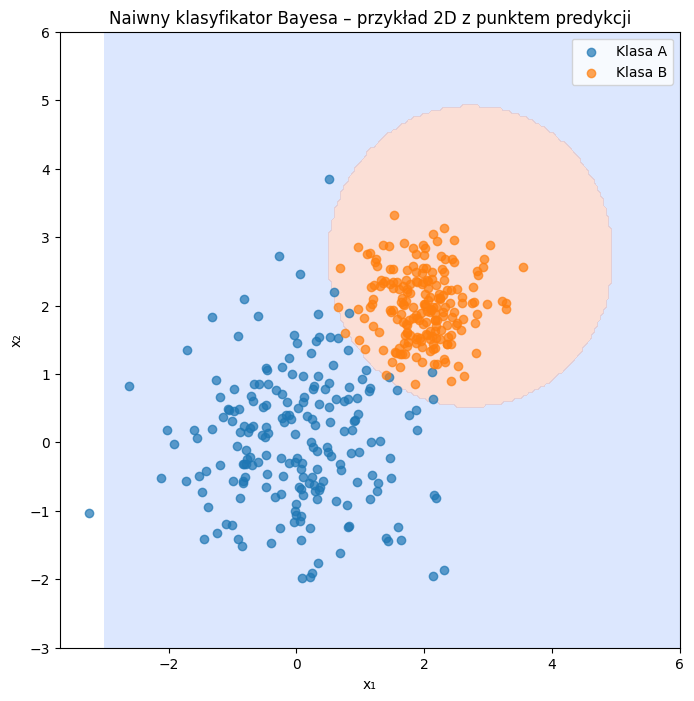

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB

# --- 1. Generowanie danych ---
np.random.seed(42)

# klasa A
A = np.random.normal(loc=[0, 0], scale=1.0, size=(200, 2))
yA = np.zeros(200)

# klasa B
B = np.random.normal(loc=[2, 2], scale=.5, size=(200, 2))
yB = np.ones(200)

# scal
X = np.vstack([A, B])
y = np.hstack([yA, yB])

# --- 2. Trenowanie klasyfikatora ---
clf = GaussianNB()
clf.fit(X, y)

# --- 3. Siatka punktów do wizualizacji ---
xx, yy = np.meshgrid(
    np.linspace(-3, 6, 200),
    np.linspace(-3, 6, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()]
pred = clf.predict(grid).reshape(xx.shape)

# --- 4. Rysowanie ---
plt.figure(figsize=(8, 8))

# obszary decyzyjne
plt.contourf(xx, yy, pred, alpha=0.3, levels=1, cmap='coolwarm')

# punkty obu klas
plt.scatter(A[:, 0], A[:, 1], label="Klasa A", alpha=0.7)
plt.scatter(B[:, 0], B[:, 1], label="Klasa B", alpha=0.7)



plt.title("Naiwny klasyfikator Bayesa – przykład 2D z punktem predykcji")
plt.legend()
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.show()

Przewidywana klasa dla punktu [4.4 4.4]: 0.0
Prawdopodobieństwa dla punktu [4.4 4.4] (Klasa 0, Klasa 1): [0.73787335 0.26212665]
P(Klasa 0 | x=[4.4 4.4]): 0.7379
P(Klasa 1 | x=[4.4 4.4]): 0.2621


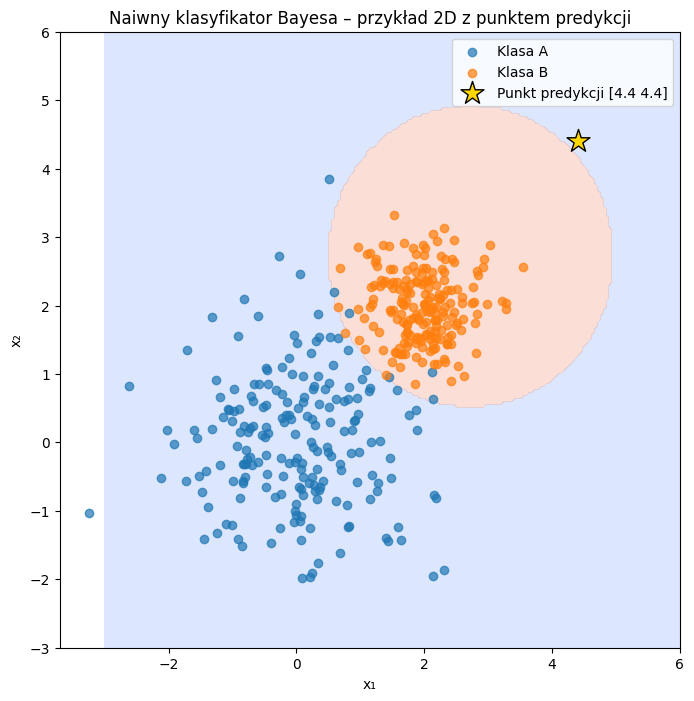

In [6]:
import numpy as np

# Punkt, dla którego chcemy dokonać predykcji
point_to_predict = np.array([[4.4,4.4]])

# Predykcja klasy
# predicted_class = gnb_classifier.predict(point_to_predict)
predicted_class = clf.predict(point_to_predict)
print(f"Przewidywana klasa dla punktu {point_to_predict.flatten()}: {predicted_class[0]}")

# Predykcja prawdopodobieństw
# predicted_probabilities = gnb_classifier.predict_proba(point_to_predict)
predicted_probabilities = clf.predict_proba(point_to_predict)
print(f"Prawdopodobieństwa dla punktu {point_to_predict.flatten()} (Klasa 0, Klasa 1): {predicted_probabilities[0]}")
print(f"P(Klasa 0 | x={point_to_predict.flatten()}): {predicted_probabilities[0][0]:.4f}")
print(f"P(Klasa 1 | x={point_to_predict.flatten()}): {predicted_probabilities[0][1]:.4f}")

# --- 4. Rysowanie ---
plt.figure(figsize=(8, 8))

# obszary decyzyjne
plt.contourf(xx, yy, pred, alpha=0.3, levels=1, cmap='coolwarm')

# punkty obu klas
plt.scatter(A[:, 0], A[:, 1], label="Klasa A", alpha=0.7)
plt.scatter(B[:, 0], B[:, 1], label="Klasa B", alpha=0.7)

# Dodanie punktu  oznaczonego gwiazdką (używając point_to_predict)
plt.scatter(point_to_predict[0, 0], point_to_predict[0, 1], marker='*', s=300, color='gold', edgecolor='black', label=f'Punkt predykcji {point_to_predict.flatten()}')

plt.title("Naiwny klasyfikator Bayesa – przykład 2D z punktem predykcji")
plt.legend()
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.show()


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (320, 2)
X_test shape: (80, 2)
y_train shape: (320,)
y_test shape: (80,)


In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Instantiate KNeighborsClassifier with k=3
kNN_classifier = KNeighborsClassifier(n_neighbors=3)

# Fit the kNN model to the training data
kNN_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred_knn = kNN_classifier.predict(X_test)

# Display the confusion matrix
print("Confusion Matrix for kNN:")
print(confusion_matrix(y_test, y_pred_knn))

# Display the classification report
print("\nClassification Report for kNN:")
print(classification_report(y_test, y_pred_knn))

Confusion Matrix for kNN:
[[42  2]
 [ 0 36]]

Classification Report for kNN:
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.98        44
         1.0       0.95      1.00      0.97        36

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80



In [9]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report

# Instantiate Gaussian Naive Bayes classifier
gnb_classifier = GaussianNB()

# Fit the GNB model to the training data
gnb_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred_gnb = gnb_classifier.predict(X_test)

# Display the confusion matrix
print("Confusion Matrix for Gaussian Naive Bayes:")
print(confusion_matrix(y_test, y_pred_gnb))

# Display the classification report
print("\nClassification Report for Gaussian Naive Bayes:")
print(classification_report(y_test, y_pred_gnb))

Confusion Matrix for Gaussian Naive Bayes:
[[43  1]
 [ 0 36]]

Classification Report for Gaussian Naive Bayes:
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99        44
         1.0       0.97      1.00      0.99        36

    accuracy                           0.99        80
   macro avg       0.99      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



#W jaki sposób można zweryfikować niezależność przed klasyfikacją?



# Przygotuj porównanie klasyfikatorów KNN i NB dla zbioru Iris



## Ktory klasyfikator jest lepszy?
W wielu praktycznych zadaniach Naive Bayes sprawdza sie lepiej, szczegolnie gdy liczba cech jest duza lub dane sa tekstowe. Model jest szybki i stabilny. KNN moze byc skuteczny, ale jego jakosc zalezy od wyboru metryki i liczby sasiadow.

## Typowe trudnosci
### Problemy KNN
- Wysokie koszty obliczen przy duzej liczbie danych, bo trzeba liczyc odleglosci do wszystkich punktow.
- Wraz ze wzrostem wymiarowosci metryka odleglosci traci sens.
- Koniecznosc skalowania danych, bo cechy o duzych wartosciach dominuja.

### Problemy Naive Bayes
- Zalozenie niezaleznosci cech jest czesto nieprawdziwe, co moze pogarszac wyniki.
- Moze miec problem, gdy w danych wystepuje cecha z wartoscia, ktora nie pojawila sie w klasie treningowej (problem zero probability).




# Weryfikacja niezaleznosci cech przed klasyfikacja

Aby sprawdzic, czy cechy sa z grubsza niezalezne przed uzyciem klasyfikatora (np. Naive Bayes), mozna wykonac kilka prostych analiz:

1. Analiza korelacji: obliczenie macierzy korelacji (np. korelacja Pearsona) i sprawdzenie, czy wartosci sa bliskie zera. Im blizej zera, tym mniejsza zaleznosc liniowa.
2. Warto narysować macierz korelacji z użyciem heatmap.
3. Testy statystyczne: dla cech ciaglych mozna stosowac testy niezaleznosci, a dla cech dyskretnych test chi kwadrat.
4. Analiza wykresow: wykresy rozrzutu dla par cech moga pokazac zaleznosci, ktore nie sa widoczne w korelacjach liczbowych.
5. Redukcja wymiarowosci: PCA lub inna metoda moze pokazac, czy cechy niosa powtarzajaca sie informacje. Silnie skorelowane cechy beda reprezentowane przez wspolne komponenty.

W praktyce cechy rzadko sa calkowicie niezalezne. Celem jest sprawdzenie, czy zaleznosci nie sa na tyle silne, by zniszczyc zalozenia modelu Naive Bayes.


--- MACIERZ KORELACJI (LICZBOWA) ---
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


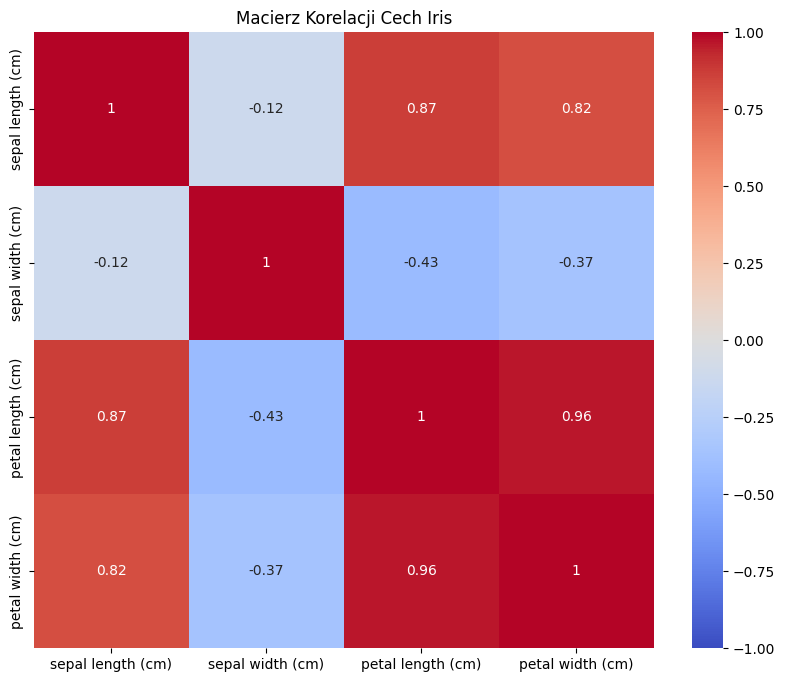

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets

# 1. Ładowanie danych do DataFrame (dla wygody)
iris = datasets.load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# 2. Obliczenie macierzy korelacji
correlation_matrix = df.corr()

# 3. Wyświetlenie wyników liczbowych
print("--- MACIERZ KORELACJI (LICZBOWA) ---")
print(correlation_matrix)

# 4. Wizualizacja (Heatmapa)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Macierz Korelacji Cech Iris")
plt.show()

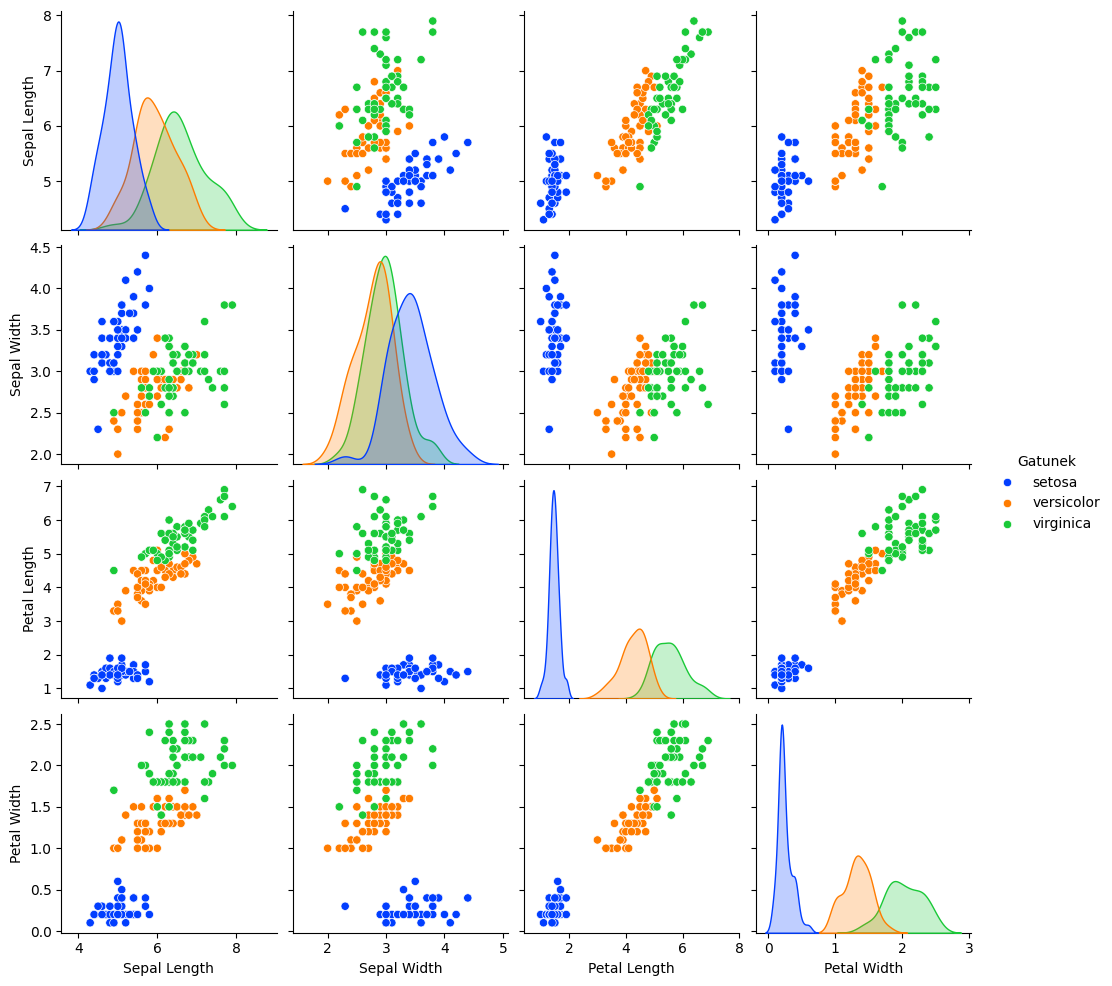

In [19]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets

# 1. Przygotowanie danych
iris = datasets.load_iris()
# Tworzymy tabelę (DataFrame), żeby Seaborn wiedział jak podpisać osie
df = pd.DataFrame(iris.data, columns=['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width'])

# Dodajemy kolumnę z nazwami gatunków (dla legendy i kolorów)
df['Gatunek'] = [iris.target_names[i] for i in iris.target]

# 2. Generowanie wykresu par (Pair Plot)
# hue='Gatunek' sprawia, że punkty są kolorowane wg gatunku
sns.pairplot(df, hue='Gatunek', palette='bright')

plt.show()

In [29]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# 1. Ładowanie zbioru danych Iris
iris = datasets.load_iris()
X = iris.data  # Cechy (długość/szerokość płatków i działek)
y = iris.target # Etykiety (0: Setosa, 1: Versicolor, 2: Virginica)

# 2. Podział na zbiór treningowy i testowy (70% trening, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Skalowanie danych (Kluczowe dla KNN!)
# Standaryzacja: średnia = 0, odchylenie = 1
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Rozmiar zbioru treningowego: {X_train.shape[0]}")
print(f"Rozmiar zbioru testowego: {X_test.shape[0]}\n")
print("--- WYNIKI KLASYFIKACJI ---\n")

# ==========================================
# MODEL 1: K-Najbliższych Sąsiadów (KNN)
# ==========================================
knn = KNeighborsClassifier(n_neighbors=5) # Szukamy 3 sąsiadów
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"Dokładność KNN (k=5): {acc_knn:.2%}")
# print(classification_report(y_test, y_pred_knn, target_names=iris.target_names)) # Opcjonalnie: pełny raport

# ==========================================
# MODEL 2: Naiwny Bayes (Gaussian NB)
# ==========================================
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

acc_gnb = accuracy_score(y_test, y_pred_gnb)
print(f"Dokładność Naive Bayes: {acc_gnb:.2%}")

# Display the classification report
print("\nClassification Report for Gaussian Naive Bayes:")
print(classification_report(y_test, y_pred_gnb))


Rozmiar zbioru treningowego: 105
Rozmiar zbioru testowego: 45

--- WYNIKI KLASYFIKACJI ---

Dokładność KNN (k=5): 100.00%
Dokładność Naive Bayes: 97.78%

Classification Report for Gaussian Naive Bayes:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



Wariancja wyjaśniona przez PC1: 72.96%
Wariancja wyjaśniona przez PC2: 22.85%
Łącznie zachowano: 95.81% informacji z oryginalnego zbioru.


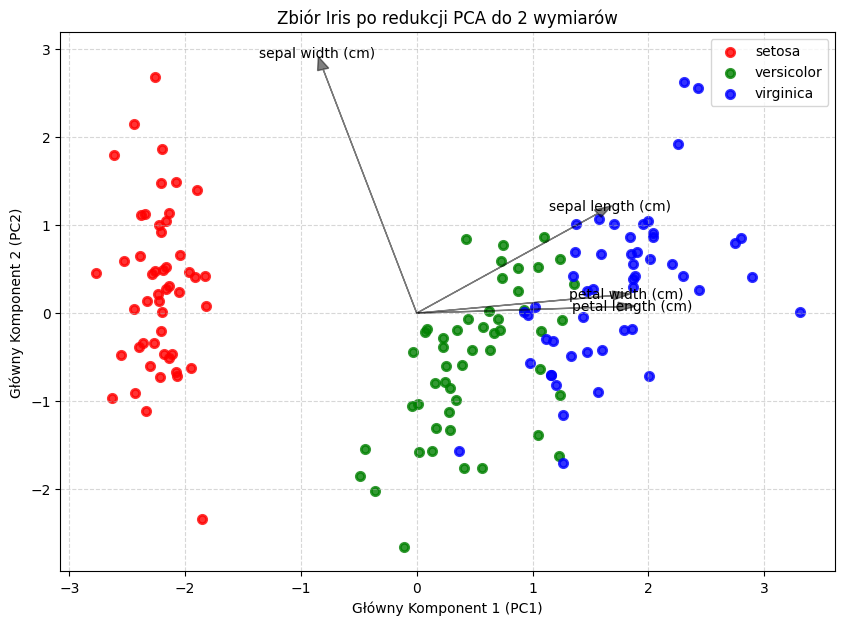

In [20]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Przygotowanie danych
iris = datasets.load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# 2. Standaryzacja (BARDZO WAŻNA przy PCA)
# PCA jest wrażliwe na skalę, więc musimy sprowadzić dane do wspólnego mianownika
X_scaled = StandardScaler().fit_transform(X)

# 3. Uruchomienie PCA - redukcja do 2 wymiarów (komponentów)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Sprawdzenie, ile informacji (wariancji) zachowaliśmy
explained_variance = pca.explained_variance_ratio_
print(f"Wariancja wyjaśniona przez PC1: {explained_variance[0]:.2%}")
print(f"Wariancja wyjaśniona przez PC2: {explained_variance[1]:.2%}")
print(f"Łącznie zachowano: {sum(explained_variance):.2%} informacji z oryginalnego zbioru.")

# 4. Wizualizacja w przestrzeni 2D
plt.figure(figsize=(10, 7))
colors = ['red', 'green', 'blue']
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], color=color, alpha=.8, lw=lw,
                label=target_name)

plt.title('Zbiór Iris po redukcji PCA do 2 wymiarów')
plt.xlabel('Główny Komponent 1 (PC1)')
plt.ylabel('Główny Komponent 2 (PC2)')
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.grid(True, linestyle='--', alpha=0.5)

# Rysowanie wektorów wpływu cech (Biplot - uproszczony)
# To pokaże, które cechy "ciągną" punkty w którą stronę
features = iris.feature_names
for i in range(len(features)):
    # Skalujemy wektory, żeby były widoczne na tle punktów
    plt.arrow(0, 0, pca.components_[0, i] * 3, pca.components_[1, i] * 3,
              color='black', alpha=0.5, head_width=0.1)
    plt.text(pca.components_[0, i] * 3.2, pca.components_[1, i] * 3.2,
             features[i], color='black', ha='center', va='center')

plt.show()

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# ==========================================
# MODEL 1: K-Najbliższych Sąsiadów (KNN)
# ==========================================
knn = KNeighborsClassifier(n_neighbors=5) # Szukamy 3 sąsiadów
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"Dokładność KNN (k=5): {acc_knn:.2%}")
# print(classification_report(y_test, y_pred_knn, target_names=iris.target_names)) # Opcjonalnie: pełny raport

# ==========================================
# MODEL 2: Naiwny Bayes (Gaussian NB)
# ==========================================
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

acc_gnb = accuracy_score(y_test, y_pred_gnb)
print(f"Dokładność Naive Bayes: {acc_gnb:.2%}")

# Display the classification report
print("\nClassification Report for Gaussian Naive Bayes:")
print(classification_report(y_test, y_pred_gnb))

Dokładność KNN (k=5): 95.56%
Dokładność Naive Bayes: 88.89%

Classification Report for Gaussian Naive Bayes:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.90      0.69      0.78        13
           2       0.75      0.92      0.83        13

    accuracy                           0.89        45
   macro avg       0.88      0.87      0.87        45
weighted avg       0.90      0.89      0.89        45



### Wnioski z porównania KNN i Naive Bayes dla zbioru Iris:

Na podstawie przeprowadzonych eksperymentów dla zbioru danych Iris, możemy zaobserwować następujące wyniki:

1.  **Bez redukcji wymiarowości (bez PCA):**
    *   **KNN (k=5):** Osiągnął doskonałą dokładność wynoszącą **100.00%**.
    *   **Naive Bayes (Gaussian NB):** Osiągnął bardzo dobrą dokładność wynoszącą **97.78%**.

    W tym scenariuszu KNN okazał się nieco lepszy, prawdopodobnie ze względu na dobrze separowalne klasy w oryginalnej przestrzeni cech i relatywnie małą liczbę wymiarów.

2.  **Po redukcji wymiarowości (z PCA do 2 komponentów):**
    *   **KNN (k=5):** Dokładność spadła do **95.56%**.
    *   **Naive Bayes (Gaussian NB):** Dokładność spadła do **88.89%**.

    Oba klasyfikatory odnotowały spadek dokładności po redukcji wymiarowości, co jest spodziewane, ponieważ część informacji została utracona. Jednakże, KNN nadal przewyższał Naiwnego Bayesa w tej zredukowanej przestrzeni.

**Ogólne wnioski:**

*   Dla zbioru Iris, **KNN wykazał się lepszą dokładnością** w obu testowanych scenariuszach (z i bez PCA).
*   Zarówno KNN, jak i Naive Bayes są skutecznymi algorytmami klasyfikacji, ale ich wydajność może się różnić w zależności od charakterystyki danych i zastosowanych technik wstępnego przetwarzania (takich jak redukcja wymiarowości).
*   Warto zauważyć, że Iris jest zbiorem danych z dobrze separowalnymi klasami, co często sprzyja algorytmom opartym na odległości, takim jak KNN.